# CRISP-DM Step 07: Model Comparison, Business Insights & Strategic Recommendations

**Project:** UCI Online Retail Data Mining Analysis  
**Phase:** CRISP-DM Step 05 (Evaluation) & Step 06 (Deployment Preparation)  

This notebook synthesizes all experimental results across Customer Clustering, Repeat Purchase Classification, and Product Association Rule Mining to derive actionable business strategies.

In [1]:
import sys
import json
from pathlib import Path
import pandas as pd
from IPython.display import display, HTML, Image, Markdown

PROJECT_ROOT = Path('.').resolve().parent if Path('.').resolve().name == 'notebooks' else Path('.').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.model_comparison import (
    validate_inputs, verify_model_artifacts,
    build_clustering_comparison, build_classification_comparison,
    build_association_comparison, validate_selected_rules,
    INPUT_FILES, TABLES_DIR, FIGURES_DIR, REPORTS_DIR, EVIDENCE_DIR
)
from src.insights import (
    build_customer_segment_insights, build_action_plan,
    build_product_association_insights, build_feature_insights
)

print("Setup complete. Root directory:", PROJECT_ROOT)

Setup complete. Root directory: D:\Project\Data-mininng


In [2]:
# 1. Input Validation and Model Artifact Checks
val_checks = validate_inputs()
print("=== Input Validation Checks ===")
for c in val_checks:
    print(" ", c)

art_checks = verify_model_artifacts()
print("\n=== Model Artifact Checks ===")
for c in art_checks:
    print(" ", c)

=== Input Validation Checks ===
  [OK] rfm_features: rfm_customer_features.csv
  [OK] repeat_features: repeat_purchase_features.csv
  [OK] customer_clusters: customer_clusters.csv
  [OK] cluster_comparison: clustering_algorithm_comparison.csv
  [OK] cluster_profiles: cluster_profiles.csv
  [OK] class_comparison: model_comparison.csv
  [OK] cv_results: cv_results.csv
  [OK] test_predictions: test_predictions.csv
  [OK] feature_importance: feature_importance.csv
  [OK] assoc_comparison: association_algorithm_comparison.csv
  [OK] selected_rules: selected_association_rules.csv
  [OK] business_insights: association_business_insights.csv
  [OK] class_metadata: classification_metadata.json



=== Model Artifact Checks ===
  [PASS] Clustering model loadable: KMeans
  [PASS] Classification pipeline loadable: Pipeline
  [PASS] Classification metadata: selected=RandomForest


,algorithm,n_clusters,silhouette_score,davies_bouldin_score,calinski_harabasz_score,dunn_approximation,noise_ratio,min_cluster_size,max_cluster_pct,runtime_seconds,is_selected,selection_reason
0,K-Means,2,0.4330,0.8917,4364.6091,0.2093,0.00,1662,61.65,0.4272,True,Silhouette=0.4330; DB=0.8917; Best combined ra...
1,K-Means,3,0.3375,1.0462,3626.2766,0.1669,0.00,763,43.22,0.0570,False,
2,K-Means,4,0.3381,1.0131,3329.6842,0.1506,0.00,686,37.75,0.1932,False,
3,K-Means,5,0.3172,0.9851,3194.6602,0.1786,0.00,312,27.57,0.3066,False,
4,K-Means,6,0.3141,1.0106,3083.6138,0.1630,0.00,317,22.82,0.1474,False,
5,K-Means,7,0.3095,0.9692,2960.3706,0.1719,0.00,219,20.51,0.1723,False,
6,K-Means,8,0.3012,0.9944,2824.3335,0.1525,0.00,214,19.54,0.1046,False,
7,GMM,2,0.2874,1.0662,2307.4172,0.1580,0.00,1505,65.27,0.4377,False,
8,GMM,3,0.2562,1.2157,2749.8992,0.1406,0.00,864,45.34,0.5566,False,
9,GMM,4,0.1752,1.7079,2167.5913,0.0885,0.00,831,34.73,0.8033,False,


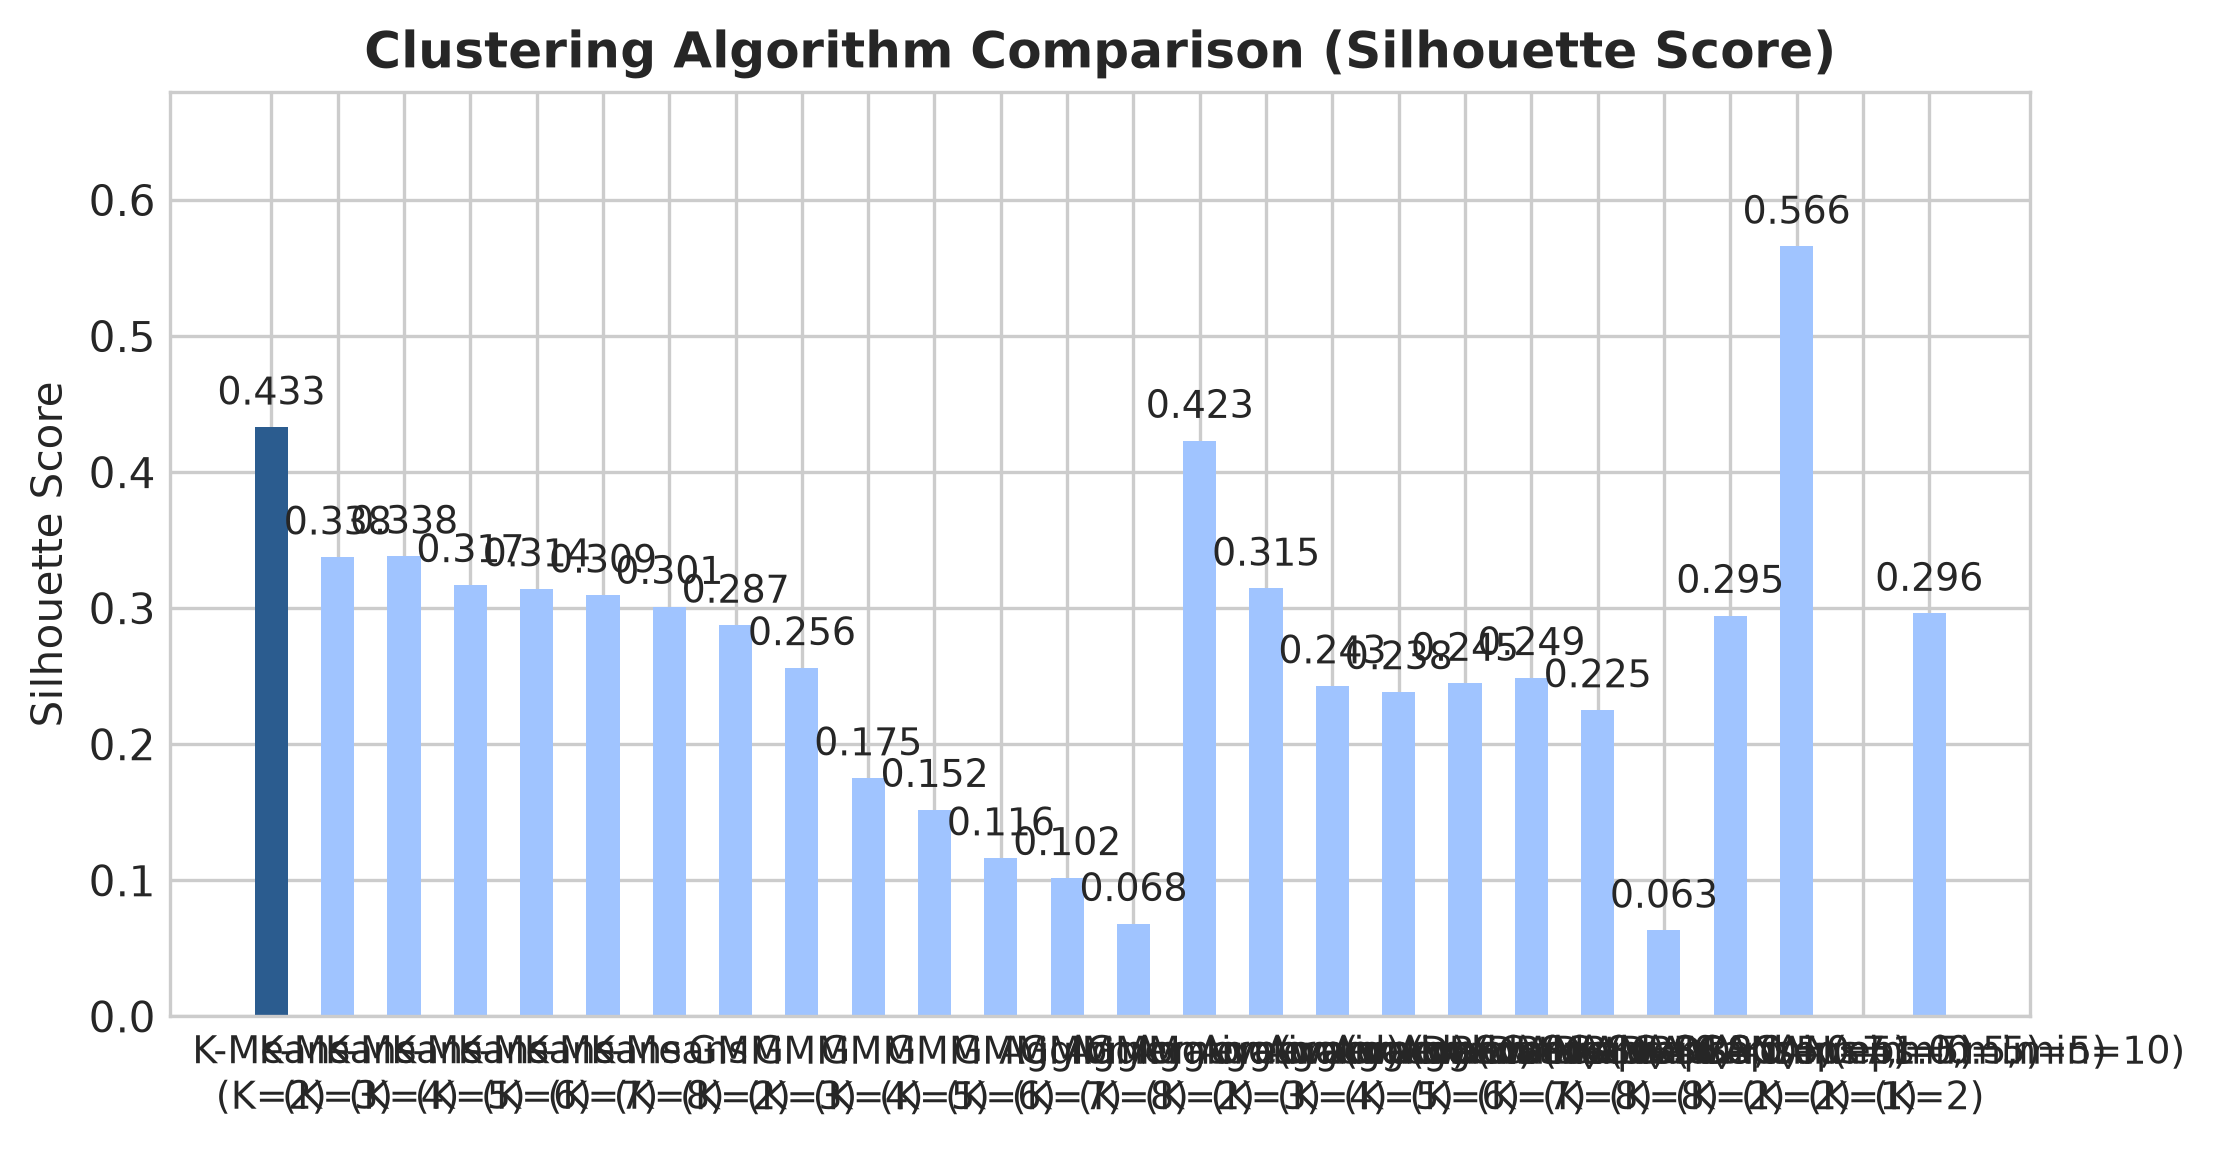

In [3]:
# 2. Customer Clustering Model Comparison
clust_comp = build_clustering_comparison()
display(HTML("<h3>Clustering Model Comparison</h3>"))
display(clust_comp)

fig_path = FIGURES_DIR / 'model_comparison' / 'clustering_model_comparison.png'
if fig_path.exists():
    display(Image(filename=str(fig_path)))

,model,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,cv_average_precision_mean,test_accuracy,test_balanced_accuracy,test_precision,test_recall,test_f1,...,tn,fp,fn,tp,runtime_seconds,selected,random_state,is_selected,selection_reason,specificity
0,DummyClassifier,0.7259,0.0003,0.5000,0.5698,0.5697,0.5000,0.5697,1.0000,0.7259,...,0,290,0,384,0.0475,False,42,False,Baseline classifier predicting majority class,0.0000
1,LogisticRegression,0.6650,0.0150,0.7323,0.8010,0.6973,0.7078,0.7941,0.6328,0.7043,...,227,63,141,243,0.0860,False,42,False,,0.7828
2,DecisionTree,0.6502,0.0162,0.6375,0.6817,0.6558,0.6557,0.7159,0.6562,0.6848,...,190,100,132,252,0.0481,False,42,False,,0.6552
3,RandomForest,0.6726,0.0191,0.6991,0.7850,0.6766,0.6744,0.7280,0.6901,0.7086,...,191,99,119,265,0.4016,True,42,True,Highest Stratified K-Fold CV F1-score (0.6726)...,0.6586


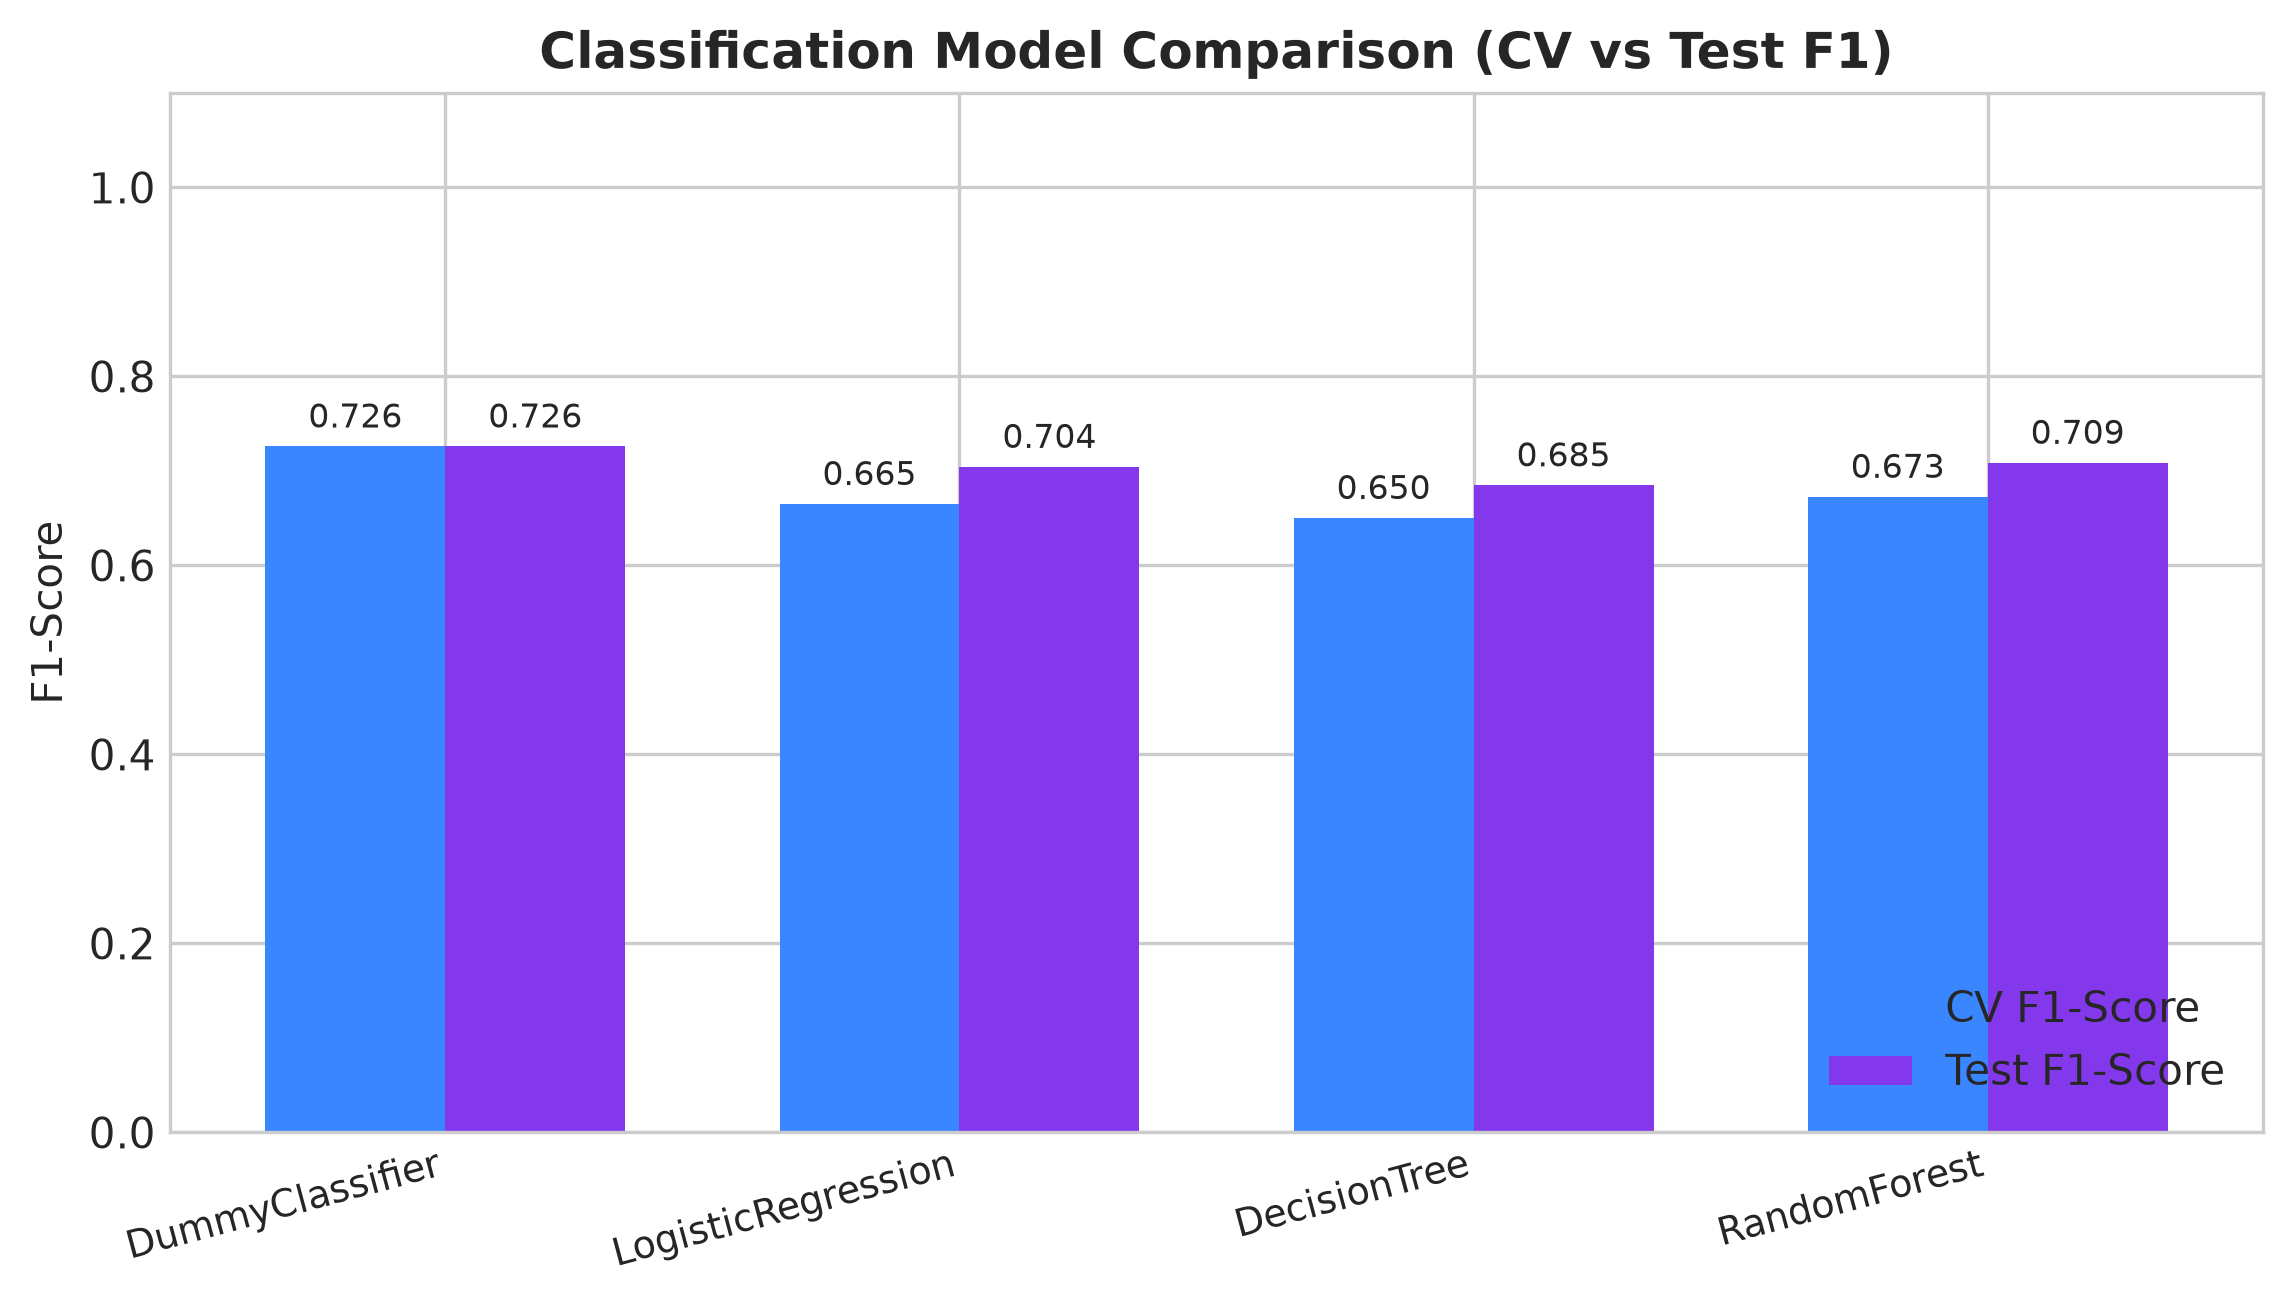

In [4]:
# 3. Classification Model Comparison
class_comp = build_classification_comparison()
display(HTML("<h3>Classification Model Comparison</h3>"))
display(class_comp)

fig_path = FIGURES_DIR / 'model_comparison' / 'classification_model_comparison.png'
if fig_path.exists():
    display(Image(filename=str(fig_path)))

In [5]:
# 4. Association Rule Mining Comparison & Quality Validation
assoc_comp = build_association_comparison()
display(HTML("<h3>Association Rules Algorithm Comparison</h3>"))
display(assoc_comp)

rule_checks, selected_rules = validate_selected_rules()
print("\n=== Association Rules Quality Checks ===")
for c in rule_checks:
    print(" ", c)

,algorithm,min_support,min_confidence,runtime_seconds,frequent_itemset_count,rule_count,valid_rule_count,max_itemset_size,max_rule_lift,is_selected,selection_reason
0,Apriori,0.02,0.5,4.61,389,61,61,3,18.231107,False,
1,FP-Growth,0.02,0.5,3.77,389,61,61,3,18.231107,True,Apriori and FP-Growth produce mathematically i...



=== Association Rules Quality Checks ===
  [PASS] Empty antecedents: 0
  [PASS] Empty consequents: 0
  [PASS] support NaN=0 Inf=0
  [PASS] confidence NaN=0 Inf=0
  [PASS] lift NaN=0 Inf=0
  [PASS] Rules with lift <= 1.0: 0
  [PASS] Rule overlap count: 0


,cluster_id,business_segment_name,customer_count,customer_percentage,recency_mean,recency_median,frequency_mean,frequency_median,monetary_mean,monetary_median,average_order_value,repeat_purchase_rate,business_interpretation,evidence_source
0,0,Best Customers,1662,38.35,25.8,16.0,8.4,6.0,4464.19,2041.33,565.22,0.9570,Recently active customers. with high purchase ...,data/processed/customer_clusters.csv + rfm_cus...
1,1,Lost Customers,2672,61.65,134.3,96.0,1.7,1.0,493.17,356.92,322.34,0.2637,Moderately active customers. with low purchase...,data/processed/customer_clusters.csv + rfm_cus...


,cluster_id,business_segment_name,strategy,recommended_action,customer_count,customer_percentage,evidence_metric
0,0,Best Customers,retention,Loyalty program — active customers with 8 avg ...,1662,38.35,"Recency=26, Freq=8, Monetary=4,464"
1,0,Best Customers,upsell,"Premium product recommendations — avg spend 4,464",1662,38.35,"Recency=26, Freq=8, Monetary=4,464"
2,0,Best Customers,cross-sell,Cross-sell bundles — 96% already repeat,1662,38.35,"Recency=26, Freq=8, Monetary=4,464"
3,1,Lost Customers,reactivation,Targeted discount — only 26% repeat rate,2672,61.65,"Recency=134, Freq=2, Monetary=493"


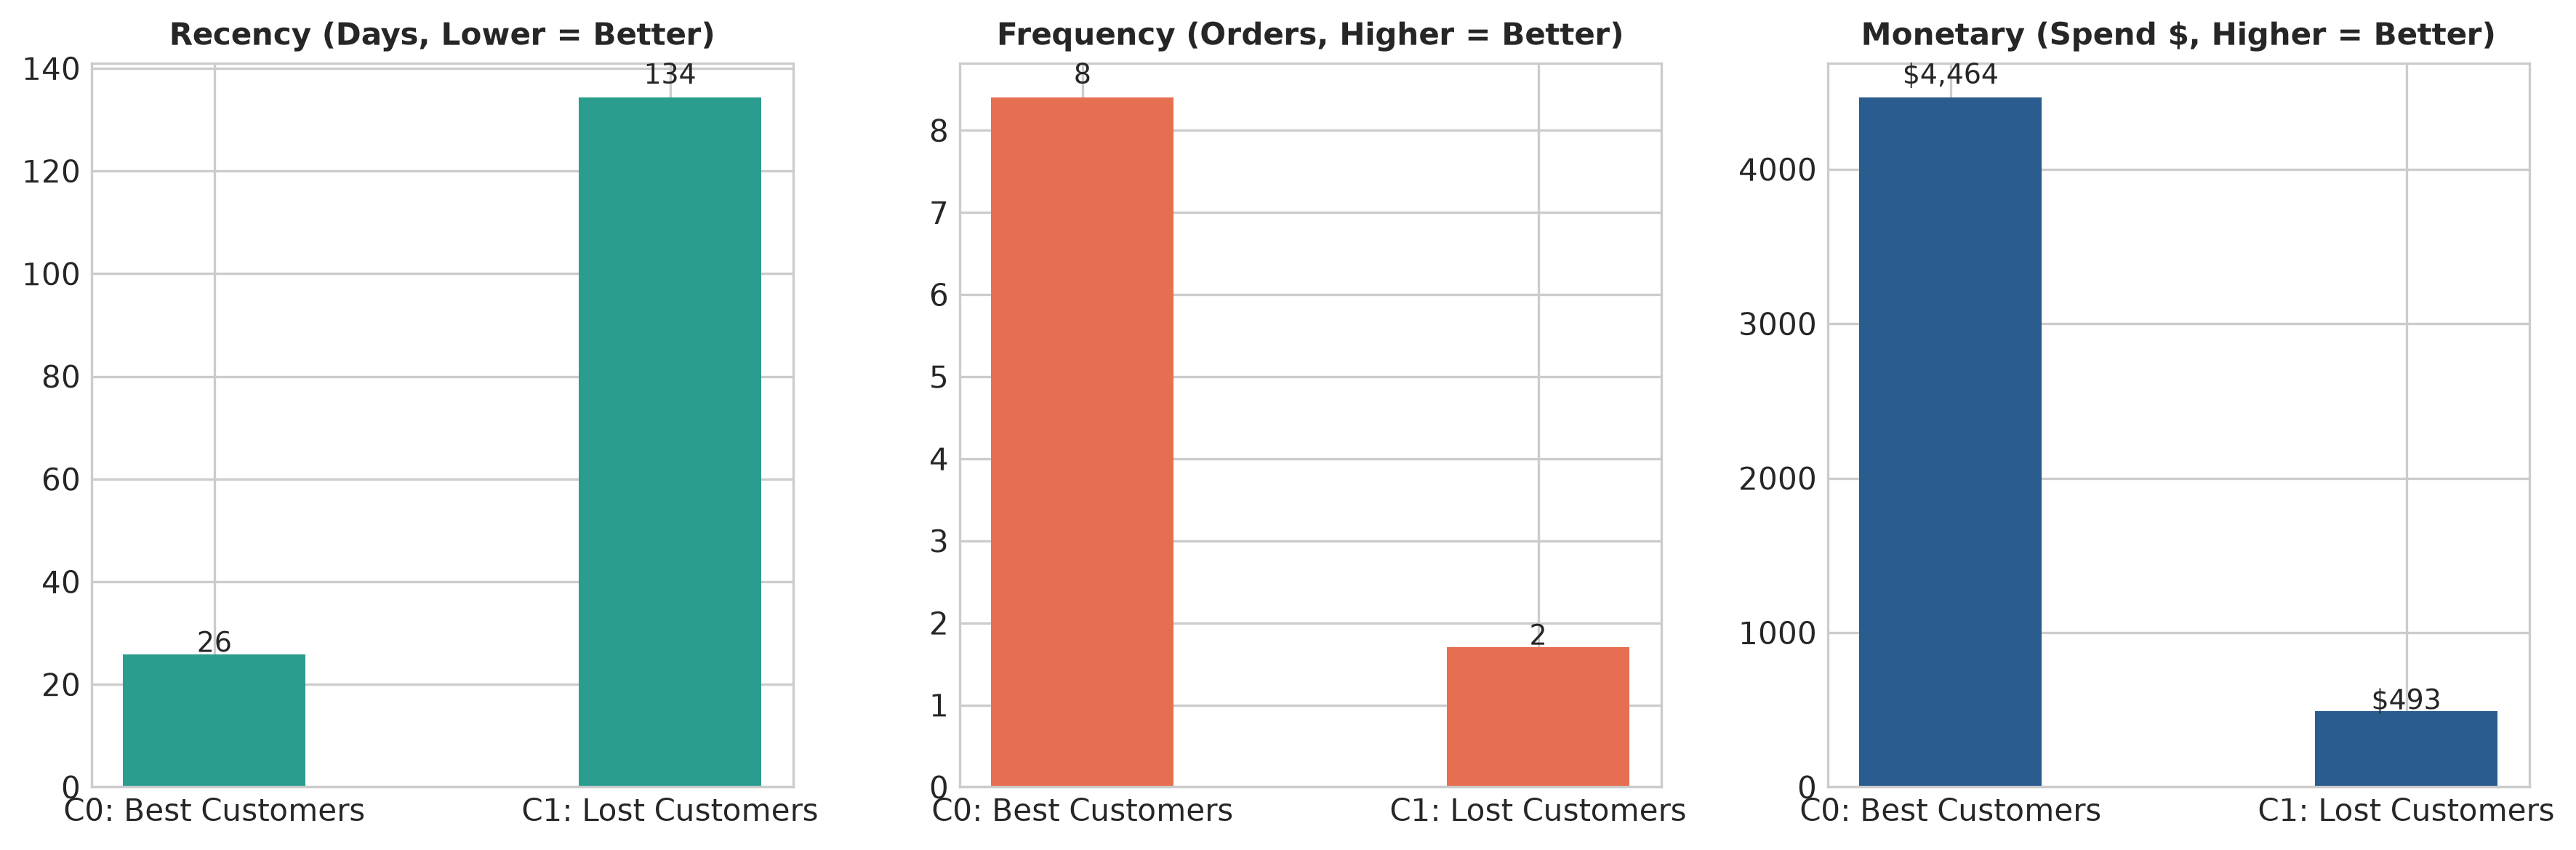

In [6]:
# 5. Customer Segment Profiles & Strategic Action Plan
seg_insights = build_customer_segment_insights()
display(HTML("<h3>Customer Segment Profiles</h3>"))
display(seg_insights)

action_plan = build_action_plan(seg_insights)
display(HTML("<h3>Segment Strategic Action Plan</h3>"))
display(action_plan)

fig_path = FIGURES_DIR / 'model_comparison' / 'segment_rfm_profile.png'
if fig_path.exists():
    display(Image(filename=str(fig_path)))

,antecedents,consequents,support,confidence,lift,conviction,evidence_quality,business_interpretation,recommended_action,limitation
0,PINK REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",0.0274,0.7072,18.23,3.2827,Weak,Customers who buy PINK REGENCY TEACUP AND SAUC...,Consider cross-selling GREEN REGENCY TEACUP AN...,Low support (0.027) — affects only a small fra...
1,"GREEN REGENCY TEACUP AND SAUCER, ROSES REGENCY...",PINK REGENCY TEACUP AND SAUCER,0.0274,0.7053,18.23,3.2625,Weak,Customers who buy GREEN REGENCY TEACUP AND SAU...,Consider cross-selling PINK REGENCY TEACUP AND...,Low support (0.027) — affects only a small fra...
2,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",GREEN REGENCY TEACUP AND SAUCER,0.0274,0.9047,17.66,9.9537,Weak,Customers who buy PINK REGENCY TEACUP AND SAUC...,Consider cross-selling GREEN REGENCY TEACUP AN...,Low support (0.027) — affects only a small fra...
3,GREEN REGENCY TEACUP AND SAUCER,"PINK REGENCY TEACUP AND SAUCER, ROSES REGENCY ...",0.0274,0.5341,17.66,2.0813,Weak,Customers who buy GREEN REGENCY TEACUP AND SAU...,Consider cross-selling PINK REGENCY TEACUP AND...,Low support (0.027) — affects only a small fra...
4,PINK REGENCY TEACUP AND SAUCER,GREEN REGENCY TEACUP AND SAUCER,0.0320,0.8261,16.13,5.4572,Moderate,Customers who buy PINK REGENCY TEACUP AND SAUC...,Consider cross-selling GREEN REGENCY TEACUP AN...,Association does not imply causation
5,GREEN REGENCY TEACUP AND SAUCER,PINK REGENCY TEACUP AND SAUCER,0.0320,0.6239,16.13,2.5559,Moderate,Customers who buy GREEN REGENCY TEACUP AND SAU...,Consider cross-selling PINK REGENCY TEACUP AND...,Association does not imply causation
6,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY ...",ROSES REGENCY TEACUP AND SAUCER,0.0274,0.8560,15.89,6.5710,Weak,Customers who buy GREEN REGENCY TEACUP AND SAU...,Consider cross-selling ROSES REGENCY TEACUP AN...,Low support (0.027) — affects only a small fra...
7,ROSES REGENCY TEACUP AND SAUCER,"GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY ...",0.0274,0.5080,15.89,1.9675,Weak,Customers who buy ROSES REGENCY TEACUP AND SAU...,Consider cross-selling GREEN REGENCY TEACUP AN...,Low support (0.027) — affects only a small fra...
8,GARDENERS KNEELING PAD CUP OF TEA,GARDENERS KNEELING PAD KEEP CALM,0.0276,0.7203,15.60,3.4104,Weak,Customers who buy GARDENERS KNEELING PAD CUP O...,Consider cross-selling GARDENERS KNEELING PAD ...,Low support (0.028) — affects only a small fra...
9,GARDENERS KNEELING PAD KEEP CALM,GARDENERS KNEELING PAD CUP OF TEA,0.0276,0.5980,15.60,2.3924,Weak,Customers who buy GARDENERS KNEELING PAD KEEP ...,Consider cross-selling GARDENERS KNEELING PAD ...,Low support (0.028) — affects only a small fra...


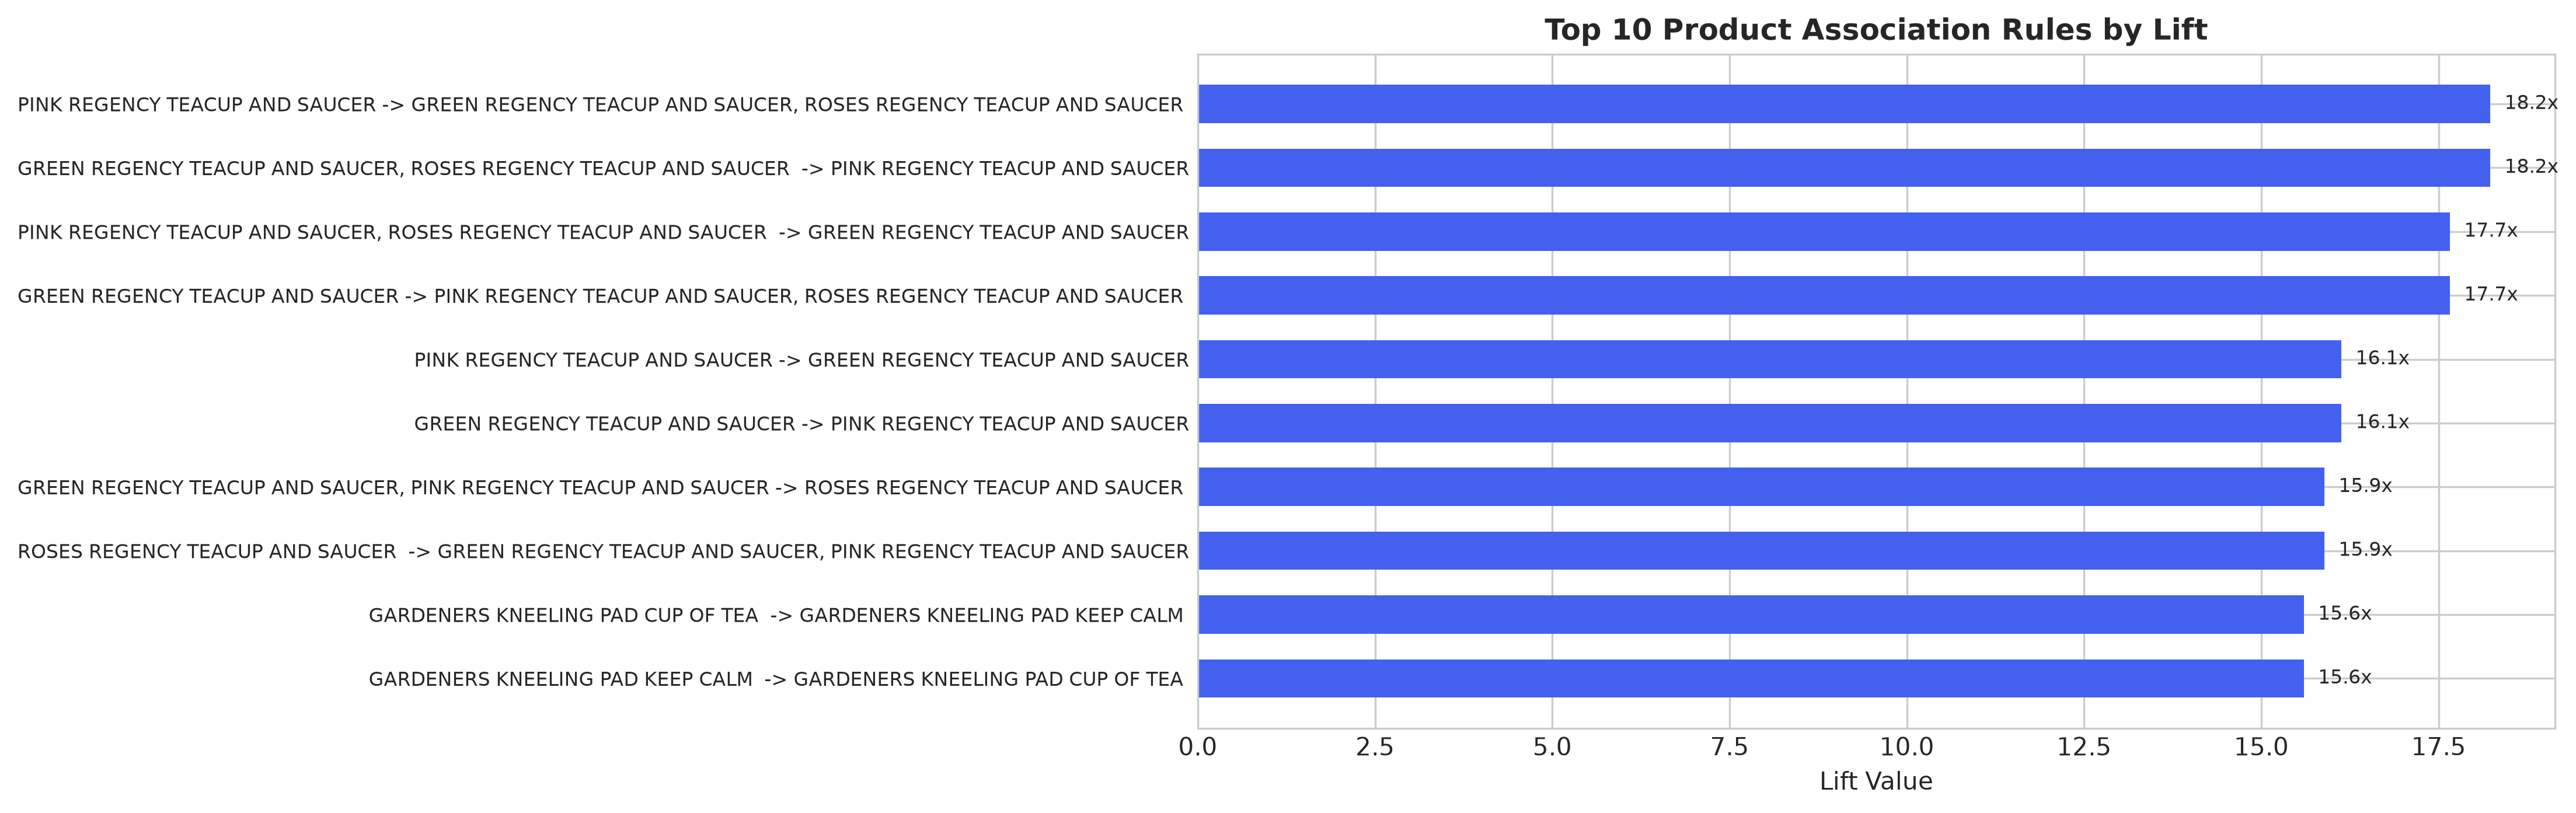

In [7]:
# 6. Product Association Rules Insights
prod_insights = build_product_association_insights()
display(HTML("<h3>Top 20 Product Association Rules</h3>"))
display(prod_insights.head(10))

fig_path = FIGURES_DIR / 'model_comparison' / 'top_association_rules.png'
if fig_path.exists():
    display(Image(filename=str(fig_path)))

,feature,importance,rank,source_model,feature_group,interpretation,limitation
0,Recency,0.139253,1,RandomForest,RFM,Top-3 most important feature (importance=0.139...,Importance is model-dependent; does not imply ...
1,Monetary,0.136043,2,RandomForest,RFM,Top-3 most important feature (importance=0.136...,Importance is model-dependent; does not imply ...
2,UniqueProducts,0.129772,3,RandomForest,Behavioral,Top-3 most important feature (importance=0.129...,Importance is model-dependent; does not imply ...
3,TotalItems,0.127866,4,RandomForest,Behavioral,Moderately important feature (importance=0.127...,Importance is model-dependent; does not imply ...
4,AverageOrderValue,0.123478,5,RandomForest,Behavioral,Moderately important feature (importance=0.123...,Importance is model-dependent; does not imply ...
5,AverageItemsPerInvoice,0.117268,6,RandomForest,Behavioral,Moderately important feature (importance=0.117...,Importance is model-dependent; does not imply ...
6,CustomerLifetimeDays,0.081577,7,RandomForest,Behavioral,Moderately important feature (importance=0.081...,Importance is model-dependent; does not imply ...
7,Frequency,0.057643,8,RandomForest,RFM,Moderately important feature (importance=0.057...,Importance is model-dependent; does not imply ...
8,ActiveDays,0.056645,9,RandomForest,Behavioral,Moderately important feature (importance=0.056...,Importance is model-dependent; does not imply ...
9,Country_United Kingdom,0.007406,10,RandomForest,Geographic,Moderately important feature (importance=0.007...,Importance is model-dependent; does not imply ...


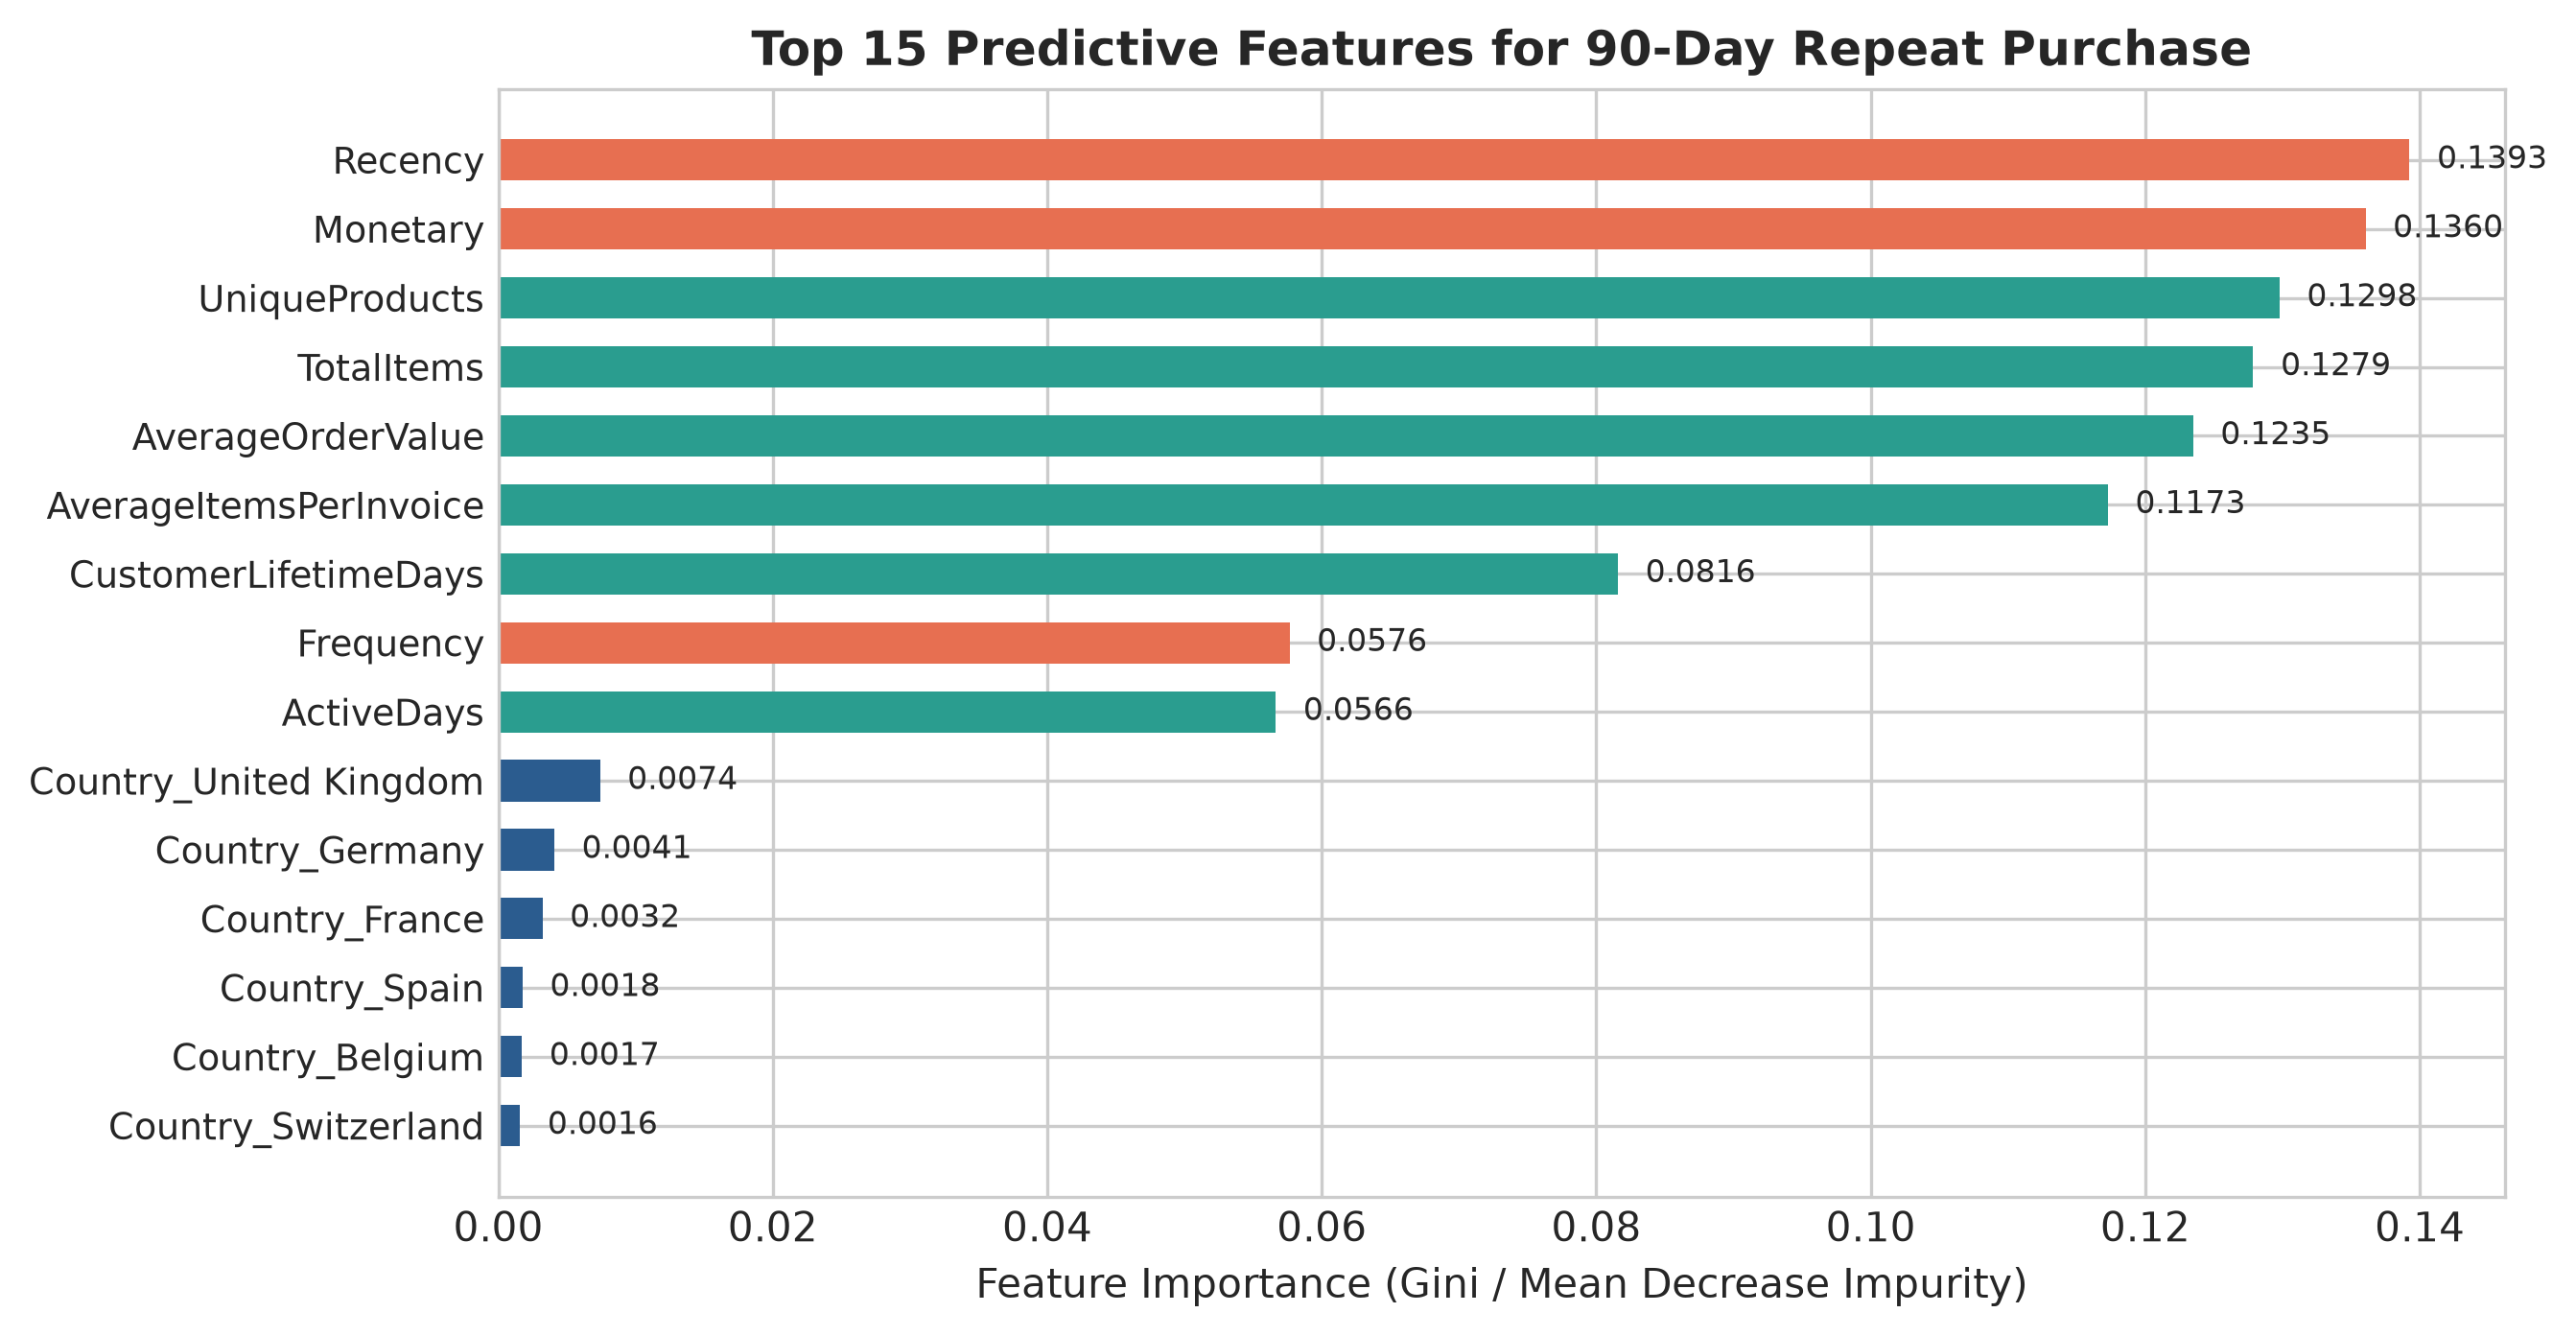

In [8]:
# 7. Feature Importance Insights
feat_insights = build_feature_insights()
display(HTML("<h3>Predictive Feature Importance Rankings</h3>"))
display(feat_insights.head(10))

fig_path = FIGURES_DIR / 'model_comparison' / 'feature_importance_top20.png'
if fig_path.exists():
    display(Image(filename=str(fig_path)))

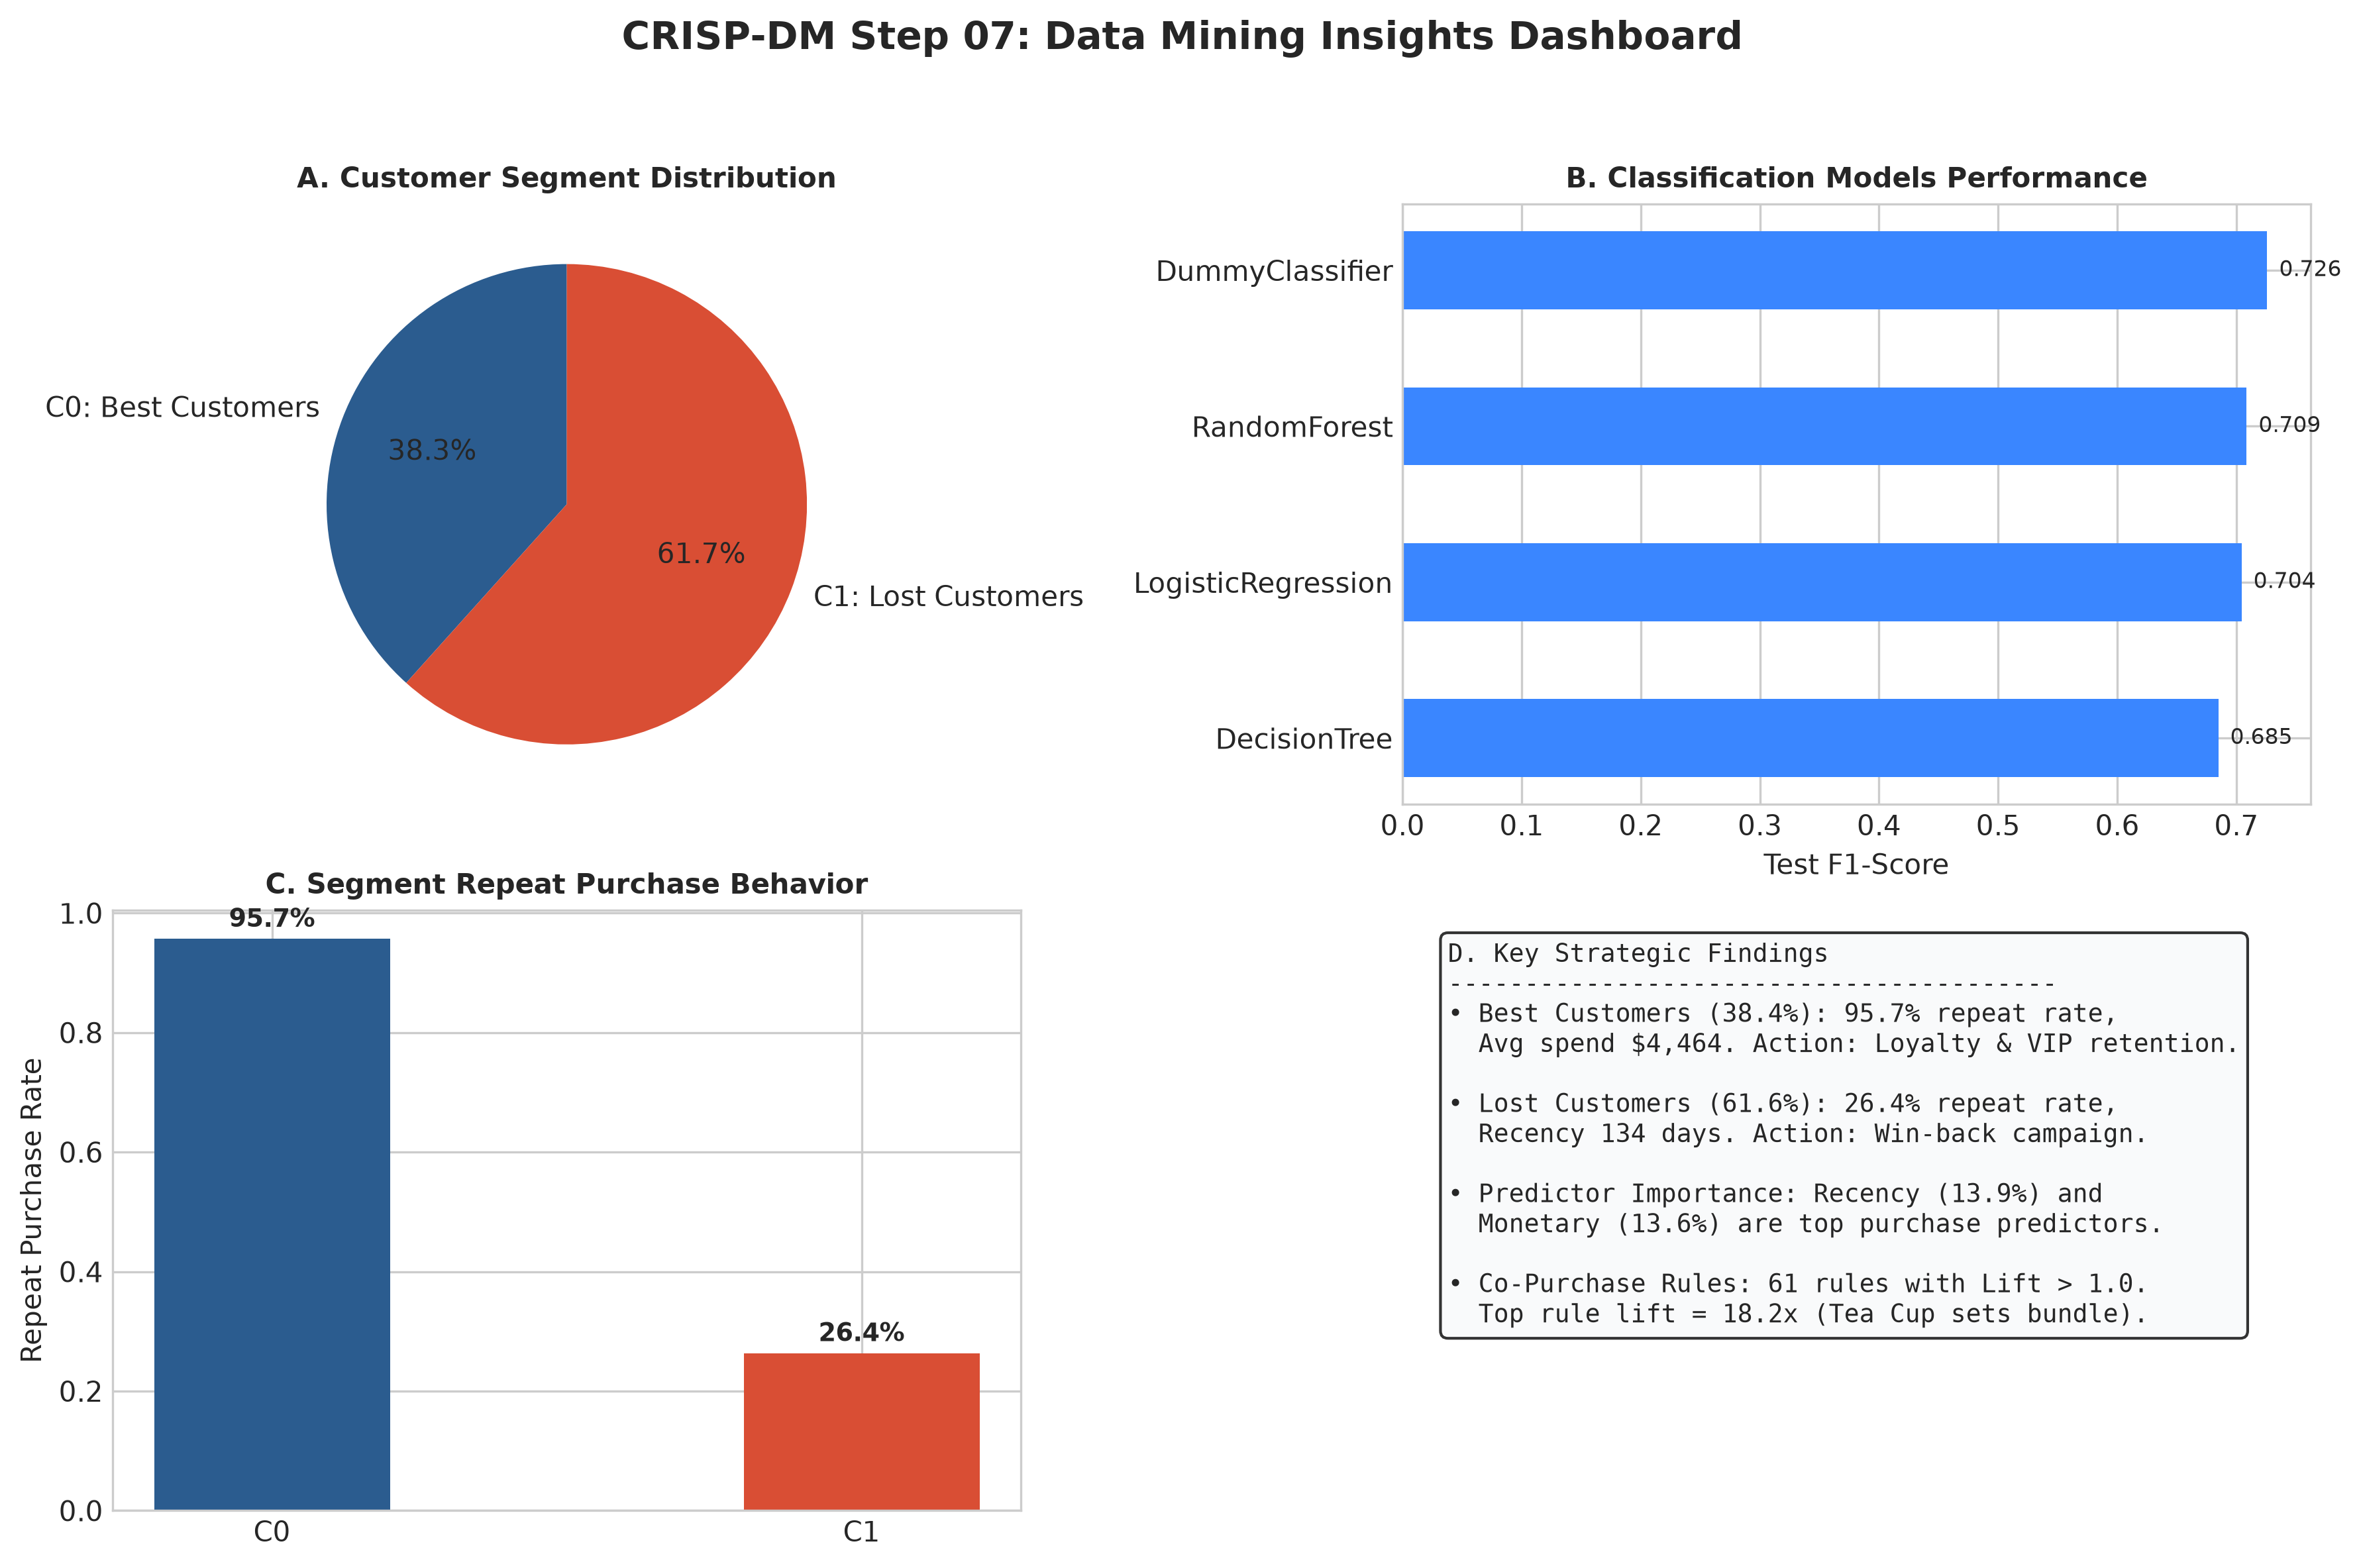

In [9]:
# 8. Executive Insight Summary Dashboard
dash_path = FIGURES_DIR / 'model_comparison' / 'insight_summary_dashboard.png'
if dash_path.exists():
    display(HTML("<h3>Executive Summary Dashboard</h3>"))
    display(Image(filename=str(dash_path)))

In [10]:
# 9. Report, Summary JSON, and Manifest Links
report_file = REPORTS_DIR / '07_model_comparison_and_insights.md'
summary_file = REPORTS_DIR / '07_model_comparison_and_insights_summary.json'
manifest_file = EVIDENCE_DIR / 'pipeline_manifest.json'

print("=== Output File Links ===")
print("Report Markdown:", report_file.relative_to(PROJECT_ROOT).as_posix() if report_file.exists() else "Missing")
print("Summary JSON:   ", summary_file.relative_to(PROJECT_ROOT).as_posix() if summary_file.exists() else "Missing")
print("Manifest JSON:  ", manifest_file.relative_to(PROJECT_ROOT).as_posix() if manifest_file.exists() else "Missing")

display(Markdown(f"""
### Step 07 Verification Complete
- [View Full Markdown Report]({report_file.relative_to(PROJECT_ROOT).as_posix()})
- [View Summary JSON]({summary_file.relative_to(PROJECT_ROOT).as_posix()})
- [View Pipeline Manifest]({manifest_file.relative_to(PROJECT_ROOT).as_posix()})
"""))

=== Output File Links ===
Report Markdown: outputs/reports/07_model_comparison_and_insights.md
Summary JSON:    outputs/reports/07_model_comparison_and_insights_summary.json
Manifest JSON:   outputs/evidence/pipeline_manifest.json



### Step 07 Verification Complete
- [View Full Markdown Report](outputs/reports/07_model_comparison_and_insights.md)
- [View Summary JSON](outputs/reports/07_model_comparison_and_insights_summary.json)
- [View Pipeline Manifest](outputs/evidence/pipeline_manifest.json)
